In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [36]:
df = pd.DataFrame(
    {
    'Session_Duration': [23, 45, 15, 67, 34, 23, 56, 23, 45, 12, 24, 38, 25, 32, 64, 58, 45, 43, 47, 52],
    'Pages_Visited': [5, 8, 2, 10, 7, 5, 9, 4, 6, 2, 5, 7, 3, 5, 9, 10, 8, 7, 6, 9],
    'Items_in_Cart': [3, 6, 1, 9, 4, 3, 7, 2, 5, 1, 4, 5, 2, 4, 8, 9, 7, 6, 5, 8],
    'Avg_Session_Value': [100, 300, 80, 450, 200, 110, 390, 90, 250, 60, 110, 230, 100, 180, 400, 410, 360, 320, 310, 380],
    'Time_Spent_on_Site': [150, 180, 70, 230, 140, 120, 200, 90, 170, 60, 110, 160, 100, 130, 240, 250, 210, 190, 180, 220],
    'Purchase_History': [5, 12, 2, 15, 10, 5, 14, 4, 10, 2, 6, 11, 3, 7, 13, 14, 12, 10, 11, 13]
}
)
df.head()

,Session_Duration,Pages_Visited,Items_in_Cart,Avg_Session_Value,Time_Spent_on_Site,Purchase_History
0,23,5,3,100,150,5
1,45,8,6,300,180,12
2,15,2,1,80,70,2
3,67,10,9,450,230,15
4,34,7,4,200,140,10


In [37]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

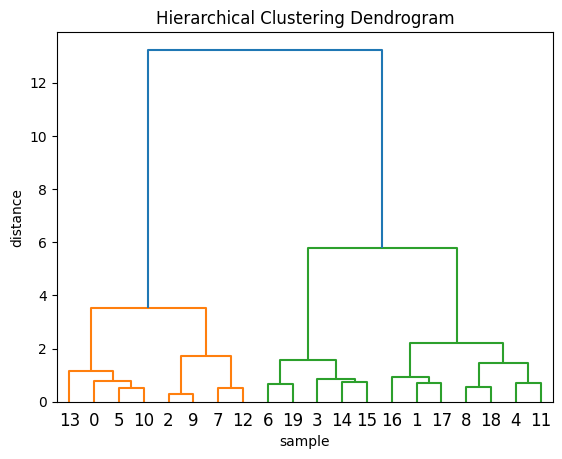

In [38]:
linkage_matrix = linkage(scaled_data, method='ward')
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample')
plt.ylabel('distance')
plt.show()

**Apply Agglomerative Clustering**

In [39]:
agg_cluster = AgglomerativeClustering(n_clusters= 2, metric = 'euclidean', linkage='ward')
cluster_labels = agg_cluster.fit_predict(scaled_data)
#add a label on dataframe
df['Cluster'] = cluster_labels

#add clustering label name
df['Cluster_name'] = df['Cluster'].map({0: 'High value customer', 1 : 'Casual Browsers'})
df.head()


,Session_Duration,Pages_Visited,Items_in_Cart,Avg_Session_Value,Time_Spent_on_Site,Purchase_History,Cluster,Cluster_name
0,23,5,3,100,150,5,1,Casual Browsers
1,45,8,6,300,180,12,0,High value customer
2,15,2,1,80,70,2,1,Casual Browsers
3,67,10,9,450,230,15,0,High value customer
4,34,7,4,200,140,10,0,High value customer


**Visualize the clastering data**

/tmp/ipykernel_662/3207527023.py:2: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(


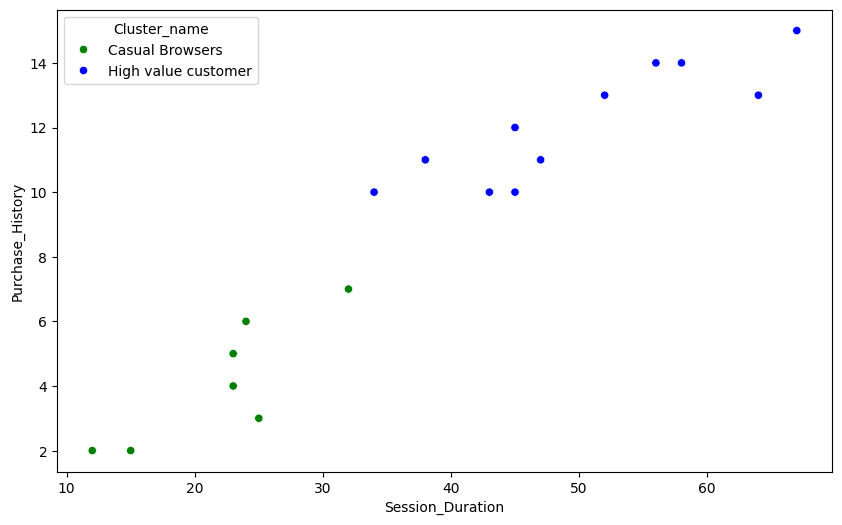

In [40]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df['Session_Duration'],
    y=df['Purchase_History'],
    hue=df['Cluster_name'],
    palette = ['green', 'blue','']
)
plt.show()